# Supplementary Fig. 8 — DCS variant calling using serial dilutions of the Myeloid Reference Standard

To assess the true- and false-positive rates of the duplex (DCS) variant calling, a commercial **Horizon
Myeloid DNA Reference Standard** (14 validated SNVs + 5 indels at defined VAFs) was sequenced, together with
serial dilutions of it into peripheral-blood DNA from one individual (hDNA), on the same lane as the cohort.

- **a** — concordance between the two technical replicates (replicate-1 vs replicate-2 VAF) for the 100 %
  standard and its 25 % / 1 % / 0.1 % dilutions; validated variants are coloured by expected VAF, other
  positions are grey.
- **b** — variant VAF in each dilution vs its VAF in the 100 % standard.

The samples are the Horizon Myeloid Reference Standard and its dilutions (`Myeloid_100/10/1/0_1`,
replicates A/B) together with the undiluted hDNA sample (`SEM11503`, replicates A/B). The hDNA is
peripheral-blood DNA from a single 65-year-old individual, used both as the diluent and, undiluted, as a
sample in its own right.

## Data availability

The per-sample variant-call files read by this notebook are **not distributed with this code**. The
Myeloid Reference Standard is commercial material, but every dilution of it, and the undiluted hDNA
sample, are largely or entirely the diluent individual's DNA, and these files report reference and variant
read depth at every panel position — which carries that individual's germline genotypes.

The observed VAF of every validated reference-standard variant, at each dilution and in both technical
replicates, is published as **Table S1** of the paper, and is included here in
`Data_files/Horizon_reference_standards/Horizon_Myeloid_Reference_DCS.xlsx`.

The sequencing data for the Myeloid Reference Standard dilutions and the hDNA sample is **not
deposited**: the EGA submission covers the UKCTOCS participant samples only. These panels therefore cannot
be re-run from public data, but every value they plot is published as **Table S1** of the paper, and is
included here in `Data_files/Horizon_reference_standards/Horizon_Myeloid_Reference_DCS.xlsx`.

| path | contents | location |
|---|---|---|
| `*_DCS_variants_MUFs_3_all_positions.vcf` | per-sample DCS calls at all panel positions (used for mean panel depth) | not distributed |
| `*_DCS_variants_MUFs_3_annotated.txt` | per-sample annotated DCS variant calls | not distributed |

The figures saved below are the output of a run with those files in place.

In [1]:
import time
start = time.time()

# imported packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import pandas as pd
import csv

end = time.time()
print(f"Imports took {end - start:.2f} seconds")

In [3]:
# Lists of colors for plots
c0 = (0.76, 0.76, 0.76)
c1 = (1.00, 0.18, 0.33);
c2 = (1.00, 0.23, 0.19);
c3 = (1.00, 0.58, 0.00);
c4 = (1.00, 0.80, 0.00);
c5 = (0.30, 0.85, 0.39);
c6 = (0.35, 0.78, 0.98);
c7 = (0.20, 0.67, 0.86);
c8 = (0.00, 0.48, 1.00);
c9 = (0.35, 0.34, 0.84);
c10 = (0.00, 0.31, 0.57);
c11 = (0.12, 0.29, 0.69);
c12 = (0.17, 0.17, 0.42);
c13 = (1.00, 1.00, 1.00);
c14 = (0.77, 0.04, 0.00);

In [4]:
#define the colors from colorbrewer2
orange1 = '#feedde'
orange2 = '#fdbe85'
orange3 = '#fd8d3c'
orange4 = '#e6550d'
orange5 = '#a63603'
blue1 = '#eff3ff'
blue2 = '#bdd7e7'
blue3 = '#6baed6'
blue4 = '#3182bd'
blue5 = '#08519c'
green1 = '#edf8e9'
green2 = '#bae4b3'
green3 = '#74c476'
green4 = '#31a354'
green5 = '#006d2c'
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'
purple1 = '#f2f0f7'
purple2 = '#cbc9e2'
purple3 = '#9e9ac8'
purple4 = '#756bb1'
purple5 = '#54278f'
red1 = '#fee5d9'
red2 = '#fcae91'
red3 = '#fb6a4a'
red4 = '#de2d26'
red5 = '#a50f15'

In [5]:
sample_names = ['Myeloid_0_1A', 'Myeloid_0_1B', 'Myeloid_1A', 'Myeloid_1B', 'Myeloid_10A', 'Myeloid_10B', 'Myeloid_100A', 'Myeloid_100B', 'SEM11503A', 'SEM11503B']

# DCS

## Read in data

### All positions

In [ ]:
#Filenames for variants in each sample...
n = 0
sample_filenames_all_positions = {}

for sample in sample_names:
    filename = 'Data_files/Horizon_reference_standards/'+sample+'_SNV_SNV_watson_code_DCS_variants_MUFs_3_all_positions.vcf'
    if os.path.isfile(filename):
        sample_filenames_all_positions[sample]=filename
    n+=1


In [17]:
def depth_across_sample(all_positions_file):
    depths_list = []

    with open(all_positions_file) as txtfile:
        reader = csv.reader(txtfile, delimiter = '\t')
        row_count = 0
        for row in reader:
            if row_count>32:
                total_depth = int(row[6].split(';')[2].split('=')[1])
                depths_list.append(total_depth)

            row_count+=1

        mean_depth = np.mean(depths_list)
        
    return mean_depth

In [18]:
samples_depths_across_panel={}

for sample, filename in sample_filenames_all_positions.items():
    mean_depth = depth_across_sample(filename)
    samples_depths_across_panel[sample]=mean_depth


### Variants

In [ ]:
#Filenames for variants in each sample...
n = 0
sample_filenames = {}

for sample in sample_names:
    filename = 'Data_files/Horizon_reference_standards/'+sample+'_SNV_SNV_watson_code_DCS_variants_MUFs_3_annotated.txt'
    if os.path.isfile(filename):
        sample_filenames[sample]=filename
    n+=1


In [20]:
def variants_list_and_dict(variants_file):
    variants_list = []
    variants_dict = {}

    with open(variants_file) as txtfile:
        reader = csv.reader(txtfile, delimiter = '\t')
        row_count = 0
        for row in reader:
            if row_count>0:
    #             print(row)
                REF = row[3]
                ALT = row[4]
                base_change = REF+'>'+ALT
                total_depth = int(row[5])
                VAF = float(row[7])
                variant_type = row[9] #e.g. SNV, Deletion, Insertion
                gene = row[10]
                AA_change = row[14]
                exonic_function = row[15]
                RSID = row[16]
                MAF_1000_genomes = row[17]
                if MAF_1000_genomes == '-':
                    MAF_1000_genomes = 0
                else:
                    MAF_1000_genomes = float(MAF_1000_genomes)
                variant_mean_UMI_family_size = float(row[23])
                mean_pos_read = float(row[24])
                mean_mapping_quality = float(row[26])
                strand_bias_phred = float(row[30])
                exac_all = row[31]
                if exac_all == '.':
                    exac_all = 0
                else:
                    exac_all = float(exac_all)
                    
                if strand_bias_phred<60:
                    if variant_mean_UMI_family_size>2:
                        if mean_pos_read >8:
#                             if variant_type == 'SNV':
                            if RSID == '-':
                                if exac_all <0.01:
                                    if total_depth >500:
                                        variants_list.append(gene+' '+AA_change)
                                        variants_dict[gene+' '+AA_change] = {'total_depth': total_depth, 'VAF': VAF, 'variant_type': variant_type, 'exonic_function':  exonic_function, 'RSID': RSID, 'MAF_1000_genomes': MAF_1000_genomes, 
                                                                             'variant_mean_UMI_family_size': variant_mean_UMI_family_size, 'mean_pos_read': mean_pos_read, 'mean_mapping_quality': mean_mapping_quality,
                                                                            'strand_bias_phred': strand_bias_phred, 'exac_all': exac_all, 'base_change': base_change}

            row_count+=1
    #         if row_count>10:
    #             break
    return variants_list, variants_dict

In [21]:
samples_variants_lists = {}
samples_variants_dicts = {}

for sample, filename in sample_filenames.items():
    variants_list, variants_dict = variants_list_and_dict(filename)
    samples_variants_lists[sample]=variants_list
    samples_variants_dicts[sample]=variants_dict

## Look at replicates

In [22]:
base_change_colors = {'A>C': '#fdd0a2',
                      'A>T': '#fd8d3c',
                      'A>G': '#a63603',
                      'G>A': '#c6dbef',
                      'G>T': '#6baed6',
                      'G>C': '#08519c',
                      'T>A': '#d4b9da',
                      'T>C': '#df65b0',
                      'T>G': '#ce1256',
                      'C>A': '#c7e9c0',
                      'C>T': '#74c476',
                      'C>G': '#006d2c'}

In [23]:
def replicates_dictionary(replicate_1, replicate_2, samples_variants_list, samples_variants_dict, samples_depths_across_panel):
    
    replicates_dict = {}
    replicates_base_change = {}
    
    list_of_all_variants = []
    rep1_variants = samples_variants_list[replicate_1]
    rep2_variants = samples_variants_list[replicate_2]
    
    for i in rep1_variants:
        list_of_all_variants.append(i)
    for i in rep2_variants:
        if i not in list_of_all_variants:
            list_of_all_variants.append(i)
            
    for variant in list_of_all_variants:
        replicates_dict[variant]=[]
        if variant in samples_variants_dict[replicate_1].keys():
            replicate_1_variant_details = samples_variants_dict[replicate_1][variant]
            r1_VAF = replicate_1_variant_details['VAF']
            replicates_dict[variant].append(r1_VAF)
            replicates_base_change[variant]=replicate_1_variant_details['base_change']
        else:
            replicates_dict[variant].append(0)
        if variant in samples_variants_dict[replicate_2].keys():
            replicate_2_variant_details = samples_variants_dict[replicate_2][variant]
            r2_VAF = replicate_2_variant_details['VAF']
            replicates_dict[variant].append(r2_VAF)
            replicates_base_change[variant]=replicate_2_variant_details['base_change']
        else:
            replicates_dict[variant].append(0)
            
    rep1_mean_depth = samples_depths_across_panel[replicate_1]
    rep2_mean_depth = samples_depths_across_panel[replicate_2]
    mean_depth = np.mean([rep1_mean_depth, rep2_mean_depth])
            
    return replicates_dict, replicates_base_change, mean_depth

In [24]:
Myeloid_100_reps, Myeloid_100_base_changes, Myeloid_100_mean_depth = replicates_dictionary('Myeloid_100A', 'Myeloid_100B', samples_variants_lists, samples_variants_dicts, samples_depths_across_panel)
Myeloid_10_reps, Myeloid_10_base_changes, Myeloid_10_mean_depth = replicates_dictionary('Myeloid_10A', 'Myeloid_10B', samples_variants_lists, samples_variants_dicts, samples_depths_across_panel)
Myeloid_1_reps, Myeloid_1_base_changes, Myeloid_1_mean_depth = replicates_dictionary('Myeloid_1A', 'Myeloid_1B', samples_variants_lists, samples_variants_dicts, samples_depths_across_panel)
Myeloid_0_1_reps, Myeloid_0_1_base_changes, Myeloid_0_1_mean_depth = replicates_dictionary('Myeloid_0_1A', 'Myeloid_0_1B', samples_variants_lists, samples_variants_dicts, samples_depths_across_panel)
SEM_reps, SEM_base_changes, SEM_mean_depth = replicates_dictionary('SEM11503A', 'SEM11503B', samples_variants_lists, samples_variants_dicts, samples_depths_across_panel)

## Look at the validated variants

In [25]:
all_validated_variants = {('chr20', 31022903, 'G>T'): 0.05,
                          ('chr11', 119148988, 'C>T'): 0.05,
                          ('chr7', 148514471, 'C>T'): 0.05,
                          ('chr13', 28592642, 'C>A'): 0.05,
                          ('chr2', 209113113, 'G>A'): 0.05,
                          ('chr15', 90631838, 'C>T'): 0.05,
                          ('chr9', 5073770, 'G>T'): 0.05,
                          ('chr12', 25398281, 'C>T'): 0.4,
                          ('chr1', 115256529, 'T>A'): 0.1,
                          ('chr21', 36206711, 'C>T'): 0.35,
                          ('chr2', 198266713, 'C>T'): 0.05,
                          ('chr4', 106164914, 'G>A'):0.05,
                          ('chr17', 7577559, 'G>A'): 0.05,
                          ('chrX', 39923086, 'G>GT'): 0.7,
                          ('chr13', 28608047): 0.05,
                          ('chr5', 170837543, 'C>CTCTG'): 0.05,
                          ('chr9', 5070021, 'TTCACAA>T'): 0.05}

validated_variant_annotation = {('chr20', 31022903, 'G>T'): ('ASXL1 p.W796C', 'SNV'),
                                ('chr11', 119148988, 'C>T'): ('CBL p.S403F', 'SNV'),
                                ('chr7', 148514471, 'C>T'): ('EZH2 p.R418Q','SNV'),
                                ('chr13', 28592642, 'C>A'): ('FLT3 p.D835Y','SNV'),
                                ('chr2', 209113113, 'G>A'): ('IDH1 p.R132C','SNV'),
                                ('chr15', 90631838, 'C>T'): ('IDH2 p.R172K','SNV'),
                                ('chr9', 5073770, 'G>T'): ('JAK2 p.V617F','SNV'),
                                ('chr12', 25398281, 'C>T'): ('KRAS p.G13D','SNV'),
                                ('chr1', 115256529, 'T>A'): ('NRAS p.Q61L','SNV'),
                                ('chr21', 36206711, 'C>T'): ('RUNX1 p.M267I','SNV'),
                                ('chr2', 198266713, 'C>T'): ('SF3B1 p.G740E','SNV'),
                                ('chr4', 106164914, 'G>A'): ('TET2 p.R1261H','SNV'),
                                ('chr17', 7577559, 'G>A'): ('TP53 p.S241F','SNV'),
                                ('chrX', 39923086, 'G>GT'): ('BCOR p.Q1174fs*8', 'insertion'),
                                ('chr13', 28608047): ('FLT3 ITD', 'insertion'),
                                ('chr5', 170837543, 'C>CTCTG'): ('NPM1 p.W288fs*12', 'insertion'),
                                ('chr9', 5070021, 'TTCACAA>T'): ('JAK2 p.F537-K539>L', 'deletion')}

In [26]:
def variants_list_and_dict_by_coordinate(variants_file):
    variants_list = []
    variants_dict = {}

    with open(variants_file) as txtfile:
        reader = csv.reader(txtfile, delimiter = '\t')
        row_count = 0
        for row in reader:
            if row_count>0:
    #             print(row)
                chromosome = row[0]
                start = int(row[1])
                stop = int(row[2])
                REF = row[3]
                ALT = row[4]
                base_change = REF+'>'+ALT
                total_depth = int(row[5])
                VAF = float(row[7])
                variant_type = row[9] #e.g. SNV, Deletion, Insertion
                gene = row[10]
                AA_change = row[14]
                exonic_function = row[15]
                RSID = row[16]
                MAF_1000_genomes = row[17]
                if MAF_1000_genomes == '-':
                    MAF_1000_genomes = 0
                else:
                    MAF_1000_genomes = float(MAF_1000_genomes)
                variant_mean_UMI_family_size = float(row[23])
                mean_pos_read = float(row[24])
                mean_mapping_quality = float(row[26])
                strand_bias_phred = float(row[30])
                exac_all = row[31]
                if exac_all == '.':
                    exac_all = 0
                else:
                    exac_all = float(exac_all)
                    
                if strand_bias_phred<60:
                    if variant_mean_UMI_family_size>2:
                        if mean_pos_read >8:
#                             if variant_type == 'SNV':
                            if RSID == '-':
                                if exac_all <0.01:
                                    if total_depth >500:
                                        variants_list.append((chromosome, start, base_change))
                                        variants_dict[(chromosome, start, base_change)] = {'total_depth': total_depth, 'VAF': VAF, 'variant_type': variant_type, 'exonic_function':  exonic_function, 'RSID': RSID, 'MAF_1000_genomes': MAF_1000_genomes, 
                                                                             'variant_mean_UMI_family_size': variant_mean_UMI_family_size, 'mean_pos_read': mean_pos_read, 'mean_mapping_quality': mean_mapping_quality,
                                                                            'strand_bias_phred': strand_bias_phred, 'exac_all': exac_all, 'base_change': base_change}

            row_count+=1
    #         if row_count>10:
    #             break
    return variants_list, variants_dict

In [27]:
samples_variants_lists_by_coordinate = {}
samples_variants_dicts_by_coordinate = {}

for sample, filename in sample_filenames.items():
    variants_list, variants_dict = variants_list_and_dict_by_coordinate(filename)
    samples_variants_lists_by_coordinate[sample]=variants_list
    samples_variants_dicts_by_coordinate[sample]=variants_dict

In [28]:
def replicates_dictionary_by_coordinate(replicate_1, replicate_2, samples_variants_list, samples_variants_dict, samples_depths_across_panel):
    
    replicates_dict = {}
    replicates_base_change = {}
    
    list_of_all_variants = []
    rep1_variants = samples_variants_list[replicate_1]
    rep2_variants = samples_variants_list[replicate_2]
    
    for i in rep1_variants:
        list_of_all_variants.append(i)
    for i in rep2_variants:
        if i not in list_of_all_variants:
            list_of_all_variants.append(i)
            
    for variant in list_of_all_variants:
        replicates_dict[variant]=[]
        if variant in samples_variants_dict[replicate_1].keys():
            replicate_1_variant_details = samples_variants_dict[replicate_1][variant]
            r1_VAF = replicate_1_variant_details['VAF']
            replicates_dict[variant].append(r1_VAF)
            replicates_base_change[variant]=replicate_1_variant_details['base_change']
        else:
            replicates_dict[variant].append(0)
        if variant in samples_variants_dict[replicate_2].keys():
            replicate_2_variant_details = samples_variants_dict[replicate_2][variant]
            r2_VAF = replicate_2_variant_details['VAF']
            replicates_dict[variant].append(r2_VAF)
            replicates_base_change[variant]=replicate_2_variant_details['base_change']
        else:
            replicates_dict[variant].append(0)
            
    rep1_mean_depth = samples_depths_across_panel[replicate_1]
    rep2_mean_depth = samples_depths_across_panel[replicate_2]
    mean_depth = np.mean([rep1_mean_depth, rep2_mean_depth])
            
    return replicates_dict, replicates_base_change, mean_depth

In [29]:
Myeloid_100_reps_coord, Myeloid_100_base_changes_coord, Myeloid_100_mean_depth = replicates_dictionary('Myeloid_100A', 'Myeloid_100B', samples_variants_lists_by_coordinate, samples_variants_dicts_by_coordinate, samples_depths_across_panel)
Myeloid_10_reps_coord, Myeloid_10_base_changes_coord, Myeloid_10_mean_depth = replicates_dictionary('Myeloid_10A', 'Myeloid_10B', samples_variants_lists_by_coordinate, samples_variants_dicts_by_coordinate, samples_depths_across_panel)
Myeloid_1_reps_coord, Myeloid_1_base_changes_coord, Myeloid_1_mean_depth = replicates_dictionary('Myeloid_1A', 'Myeloid_1B', samples_variants_lists_by_coordinate, samples_variants_dicts_by_coordinate, samples_depths_across_panel)
Myeloid_0_1_reps_coord, Myeloid_0_1_base_changes_coord, Myeloid_0_1_mean_depth = replicates_dictionary('Myeloid_0_1A', 'Myeloid_0_1B', samples_variants_lists_by_coordinate, samples_variants_dicts_by_coordinate, samples_depths_across_panel)
SEM_reps_coord, SEM_base_changes_coord, SEM_mean_depth = replicates_dictionary('SEM11503A', 'SEM11503B', samples_variants_lists_by_coordinate, samples_variants_dicts_by_coordinate, samples_depths_across_panel)

In [30]:
color70 = c7
color40 = c5
color35 = c4
color10 = c3
color5 = c1

In [31]:
color5 = '#e31a1c'
color10 = 'mediumpurple'
color35 = 'deepskyblue'
color40 = 'gold'
color70 = 'LimeGreen'

In [ ]:
def plot_validated_replicates_zoomed_in(reps_dictionary, base_changes_dictionary, mean_depth, title, sample_name, DCS_or_SSCS, dilution_factor, variants_to_add): #variants_to_add = [(VAF1, VAF2, expected_VAF)...]
    fig, ax1 = plt.subplots(1, 1, figsize = (6.5, 6))

    axislabelfont = 16
    
    rep1_less_05 = 0
    rep2_less_05 =0 
    rep1_total = 0
    rep2_total = 0
    rep_both_total = 0
    rep_both_less_05 = 0
    rep1_but_not_rep2 = 0
    rep2_but_not_rep1 = 0

    x = []
    y = []
    colors = []
    for variant, VAFs in reps_dictionary.items():
        if variant not in all_validated_variants.keys():
            rep1_VAF = float(VAFs[0])
            rep2_VAF = float(VAFs[1])
            if rep1_VAF == 0:
                rep1_VAF = 1e-4
            if rep2_VAF == 0:
                rep2_VAF = 1e-4
            x.append(rep1_VAF)
            y.append(rep2_VAF)
            colors.append(grey1)
            
    ax1.scatter(x, y, color = colors, zorder = 500, s = 120, lw = 0.7, edgecolor = grey4, alpha =1.0)
            
    x = []
    y = []
    colors = []
    for variant, VAFs in reps_dictionary.items():
        if variant in all_validated_variants.keys():
            variant_type = validated_variant_annotation[variant][1]
            rep1_VAF = float(VAFs[0])
            rep2_VAF = float(VAFs[1])
            if rep1_VAF == 0:
                rep1_VAF = 1e-4
            if rep2_VAF == 0:
                rep2_VAF = 1e-4
            x.append(rep1_VAF)
            y.append(rep2_VAF)
            expected_VAF = all_validated_variants[variant]
#             if variant_type == 'SNV':
#                 colors.append(c1)
#             if variant_type == 'insertion':
#                 colors.append(c6)
#             if variant_type == 'deletion':
#                 colors.append(c9)
                
            if expected_VAF == 0.7:
                colors.append(color70)
            if expected_VAF == 0.4:
                colors.append(color40)
            if expected_VAF == 0.35:
                colors.append(color35)
            if expected_VAF == 0.1:
                colors.append(color10)
            if expected_VAF == 0.05:
                colors.append(color5)

    for variant in all_validated_variants.keys():
        annotation = validated_variant_annotation[variant]
        expected_VAF = all_validated_variants[variant]
        if variant in reps_dictionary.keys():
            print(annotation[0]+' '+str(expected_VAF)+': '+str(reps_dictionary[variant]))
        else:
            print(annotation[0]+' '+str(expected_VAF)+': not_detected')
        
    ax1.scatter(x, y, color = colors, zorder = 500, s = 140, lw = 0.7, edgecolor = 'k', alpha = 1.0) 
    
    x = []
    y = []
    colors = []
    for i in variants_to_add:
        x.append(i[0])
        y.append(i[1])
        expected_VAF = i[2]
        if expected_VAF == 0.7:
            colors.append(color70)
        if expected_VAF == 0.4:
            colors.append(color40)
        if expected_VAF == 0.35:
            colors.append(color35)
        if expected_VAF == 0.1:
            colors.append(color10)
        if expected_VAF == 0.05:
            colors.append(color5)
                
    ax1.scatter(x, y, color = colors, zorder = 500, s = 140, lw = 0.7, edgecolor = 'k', alpha = 1.0) 
    

    ax1.plot([1e-5, 1], [1e-5, 1], color = grey5, lw = 1.5, linestyle = ':', zorder = 50)
    
    
    ax1.plot([1e-4, 1], [0.7/dilution_factor, 0.7/dilution_factor], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    ax1.plot([0.7/dilution_factor, 0.7/dilution_factor], [1e-4, 1], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    
    ax1.plot([1e-4, 1], [0.4/dilution_factor, 0.4/dilution_factor], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    ax1.plot([0.4/dilution_factor, 0.4/dilution_factor], [1e-4, 1], color = grey3, lw = 1, linestyle = ':', zorder = 50)

    ax1.plot([1e-4, 1], [0.35/dilution_factor, 0.35/dilution_factor], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    ax1.plot([0.35/dilution_factor, 0.35/dilution_factor], [1e-4, 1], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    
    ax1.plot([1e-4, 1], [0.1/dilution_factor, 0.1/dilution_factor], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    ax1.plot([0.1/dilution_factor, 0.1/dilution_factor], [1e-4, 1], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    
    ax1.plot([1e-4, 1], [0.05/dilution_factor, 0.05/dilution_factor], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    ax1.plot([0.05/dilution_factor, 0.05/dilution_factor], [1e-4, 1], color = grey3, lw = 1, linestyle = ':', zorder = 50)

    #Error lines
    D = mean_depth
    print('mean depth =', mean_depth)
    x1=np.logspace(-4, 0, 10000)
    y1=np.logspace(-4, 0, 10000)
    f_low=[f-1.96*((f/D)**0.5) for f in x1]
    f_low2=[]
    for f in f_low:
        if f<0:
            f_low2.append(1e-8)
        else:
            f_low2.append(f)
    ax1.plot(x1, f_low2, lw=1.5,color=grey5,alpha=1.0, zorder=2, ls=':')
    ax1.plot(f_low2, x1, lw=1.5,color=grey5,alpha=1.0, zorder=2, ls=':')

    #Configure appearance of plot
    for ax in [ax1]:
#         ax.set_xlim(8e-6, 1)
#         ax.set_ylim(8e-6, 1)
        
        ax.set_xlim(0.01, 1)
        ax.set_ylim(0.01, 1)

        ax.set_xscale('log')
        ax.set_yscale('log')

        ax.set_xlabel('replicate 1 VAF (%)', fontsize = 16)
        ax.set_ylabel('replicate 2 VAF (%)', fontsize = 16)
        ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 16)
        ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
        for axis in ['right', 'top']:
            ax.spines[axis].set_visible(False)
        for axis in ['bottom', 'left']:
            ax.spines[axis].set_linewidth(1.5)
            ax.spines[axis].set_color(grey4)

        x_major_ticks = [10**(-2), 0.05, 10**(-1), 0.35, 0.4, 0.7, 10**(0)]
        x_major_tick_labels = ["1", "5", "10", "35", "40", "70", "100"]
        ax.set_xticks(x_major_ticks)
        ax.set_xticklabels(x_major_tick_labels, fontsize = axislabelfont)
        ax.set_yticks(x_major_ticks)
        ax.set_yticklabels(x_major_tick_labels, fontsize = axislabelfont)

        ax.grid(which = 'both', zorder = 0, color = grey2)

    ax1.set_title(sample_name+' '+DCS_or_SSCS, fontsize = 16)
    
    base_change_list = []
    custom_lines = []
    for base_change, coloring in base_change_colors.items():
        custom_lines.append(Line2D([0], [0], color=coloring, lw=0, marker = 'o', markersize = 8))
        base_change_list.append(base_change)
        
    custom_lines=[Line2D([0], [0], color=color70, lw=0, marker = 'o', markersize = 10),
                   Line2D([0], [0], color=color40, lw=0, marker = 'o', markersize = 10),
                    Line2D([0], [0], color=color35, lw=0, marker = 'o', markersize = 10),
                     Line2D([0], [0], color=color10, lw=0, marker = 'o', markersize = 10),
                      Line2D([0], [0], color=color5, lw=0, marker = 'o', markersize = 10)]

    VAFs = ['70%', '40%', '35%', '10%', '5%']
#         
    ax1.legend(custom_lines, VAFs, fontsize = 12, loc='lower left', bbox_to_anchor=(-0.08, 1.05), ncol = 5)
    
    print()
    print('total variants in replicate 1 = ', rep1_total)
    print('total variants in replicate 1 <0.5% VAF = ', rep1_less_05)
    print('total variants in replicate 2 = ', rep2_total)
    print('total variants in replicate 2 <0.5% VAF = ', rep2_less_05)
    print('total variants present in both replicate 1 and 2 = ', rep_both_total)
    print('total variants present in both replicate 1 and 2 <0.5% VAF = ', rep_both_less_05)
    print('total variants present in replicate 1 but not replicate 2 = ', rep1_but_not_rep2)
    print('total variants present in replicate 2 but not replicate 1 = ', rep2_but_not_rep1)
    
    plt.tight_layout()

    return plt.show()

ASXL1 p.W796C 0.05: [0.04823865439543002, 0.047188360204482895]
CBL p.S403F 0.05: [0.04692982456140351, 0.051643192488262914]
EZH2 p.R418Q 0.05: [0.04016814572629612, 0.04429611650485437]
FLT3 p.D835Y 0.05: [0.0436046511627907, 0.044]
IDH1 p.R132C 0.05: [0.05062703204830469, 0.0456989247311828]
IDH2 p.R172K 0.05: [0.04356132976690867, 0.049951969260326606]
JAK2 p.V617F 0.05: [0.04358593363051015, 0.05794831636648395]
KRAS p.G13D 0.4: [0.37265527303042933, 0.3587174348697395]
NRAS p.Q61L 0.1: [0.08565022421524664, 0.09078947368421053]
RUNX1 p.M267I 0.35: [0.3402575820523473, 0.32782515991471217]
SF3B1 p.G740E 0.05: [0.046052631578947366, 0.04804560260586319]
TET2 p.R1261H 0.05: [0.048963387737097484, 0.043764988009592325]
TP53 p.S241F 0.05: [0.04821664464993395, 0.05128205128205128]
BCOR p.Q1174fs*8 0.7: [0.592170818505338, 0.6064769381746811]
FLT3 ITD 0.05: not_detected
NPM1 p.W288fs*12 0.05: [0.041592394533571005, 0.03940886699507389]
JAK2 p.F537-K539>L 0.05: [0.036702127659574466, 0.

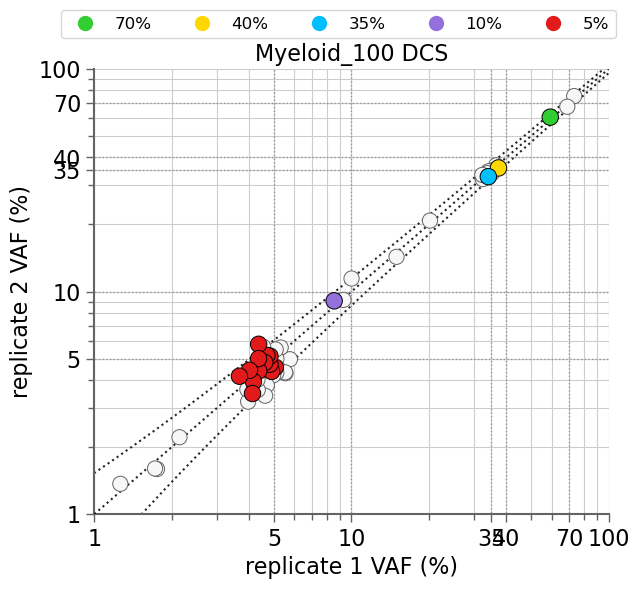

In [33]:
plot_validated_replicates_zoomed_in(Myeloid_100_reps_coord, Myeloid_100_base_changes_coord, Myeloid_100_mean_depth, 'Myeloid 100%', 'Myeloid_100', 'DCS', 1, [(0.041, 0.035, 0.05)])

In [ ]:
def plot_validated_replicates_zoomed_in_10_dilution(reps_dictionary, base_changes_dictionary, mean_depth, title, sample_name, DCS_or_SSCS, dilution_factor, variants_to_add):
    fig, ax1 = plt.subplots(1, 1, figsize = (6.5, 6))

    axislabelfont = 16
    
    rep1_less_05 = 0
    rep2_less_05 =0 
    rep1_total = 0
    rep2_total = 0
    rep_both_total = 0
    rep_both_less_05 = 0
    rep1_but_not_rep2 = 0
    rep2_but_not_rep1 = 0

    x = []
    y = []
    colors = []
    for variant, VAFs in reps_dictionary.items():
        if variant not in all_validated_variants.keys():
            rep1_VAF = float(VAFs[0])
            rep2_VAF = float(VAFs[1])
            if rep1_VAF == 0:
                rep1_VAF = 1e-4
            if rep2_VAF == 0:
                rep2_VAF = 1e-4
            x.append(rep1_VAF)
            y.append(rep2_VAF)
            colors.append(grey1)
            
    ax1.scatter(x, y, color = colors, zorder = 500, s = 120, lw = 0.7, edgecolor = grey4, alpha =1.0)
            
    x = []
    y = []
    colors = []
    for variant, VAFs in reps_dictionary.items():
        if variant in all_validated_variants.keys():
            variant_type = validated_variant_annotation[variant][1]
            rep1_VAF = float(VAFs[0])
            rep2_VAF = float(VAFs[1])
            if rep1_VAF == 0:
                rep1_VAF = 1e-4
            if rep2_VAF == 0:
                rep2_VAF = 1e-4
            x.append(rep1_VAF)
            y.append(rep2_VAF)
            expected_VAF = all_validated_variants[variant]
#             if variant_type == 'SNV':
#                 colors.append(c1)
#             if variant_type == 'insertion':
#                 colors.append(c6)
#             if variant_type == 'deletion':
#                 colors.append(c9)
                
            if expected_VAF == 0.7:
                colors.append(color70)
            if expected_VAF == 0.4:
                colors.append(color40)
            if expected_VAF == 0.35:
                colors.append(color35)
            if expected_VAF == 0.1:
                colors.append(color10)
            if expected_VAF == 0.05:
                colors.append(color5)

    for variant in all_validated_variants.keys():
        annotation = validated_variant_annotation[variant]
        expected_VAF = all_validated_variants[variant]
        if variant in reps_dictionary.keys():
            print(annotation[0]+' '+str(expected_VAF)+': '+str(reps_dictionary[variant]))
        else:
            print(annotation[0]+' '+str(expected_VAF)+': not_detected')
        
    ax1.scatter(x, y, color = colors, zorder = 500, s = 140, lw = 0.7, edgecolor = 'k', alpha = 1.0)    
    
    
    x = []
    y = []
    colors = []
    for i in variants_to_add:
        x.append(i[0])
        y.append(i[1])
        expected_VAF = i[2]
        if expected_VAF == 0.7:
            colors.append(color70)
        if expected_VAF == 0.4:
            colors.append(color40)
        if expected_VAF == 0.35:
            colors.append(color35)
        if expected_VAF == 0.1:
            colors.append(color10)
        if expected_VAF == 0.05:
            colors.append(color5)
                
    ax1.scatter(x, y, color = colors, zorder = 500, s = 140, lw = 0.7, edgecolor = 'k', alpha = 1.0) 

    ax1.plot([1e-5, 1], [1e-5, 1], color = grey5, lw = 1.5, linestyle = ':', zorder = 50)
    
    
    ax1.plot([1e-4, 1], [0.7/dilution_factor, 0.7/dilution_factor], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    ax1.plot([0.7/dilution_factor, 0.7/dilution_factor], [1e-4, 1], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    
    ax1.plot([1e-4, 1], [0.4/dilution_factor, 0.4/dilution_factor], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    ax1.plot([0.4/dilution_factor, 0.4/dilution_factor], [1e-4, 1], color = grey3, lw = 1, linestyle = ':', zorder = 50)

    ax1.plot([1e-4, 1], [0.35/dilution_factor, 0.35/dilution_factor], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    ax1.plot([0.35/dilution_factor, 0.35/dilution_factor], [1e-4, 1], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    
    ax1.plot([1e-4, 1], [0.1/dilution_factor, 0.1/dilution_factor], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    ax1.plot([0.1/dilution_factor, 0.1/dilution_factor], [1e-4, 1], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    
    ax1.plot([1e-4, 1], [0.05/dilution_factor, 0.05/dilution_factor], color = grey3, lw = 1, linestyle = ':', zorder = 50)
    ax1.plot([0.05/dilution_factor, 0.05/dilution_factor], [1e-4, 1], color = grey3, lw = 1, linestyle = ':', zorder = 50)

    #Error lines
    D = mean_depth
    x1=np.logspace(-4, 0, 10000)
    y1=np.logspace(-4, 0, 10000)
    f_low=[f-1.96*((f/D)**0.5) for f in x1]
    f_low2=[]
    for f in f_low:
        if f<0:
            f_low2.append(1e-8)
        else:
            f_low2.append(f)
    ax1.plot(x1, f_low2, lw=1.5,color=grey5,alpha=1.0, zorder=2, ls=':')
    ax1.plot(f_low2, x1, lw=1.5,color=grey5,alpha=1.0, zorder=2, ls=':')

    #Configure appearance of plot
    for ax in [ax1]:
#         ax.set_xlim(8e-6, 1)
#         ax.set_ylim(8e-6, 1)
        
        ax.set_xlim(0.01, 0.5)
        ax.set_ylim(0.01, 0.5)

        ax.set_xscale('log')
        ax.set_yscale('log')

        ax.set_xlabel('replicate 1 VAF (%)', fontsize = 16)
        ax.set_ylabel('replicate 2 VAF (%)', fontsize = 16)
        ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 16)
        ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
        for axis in ['right', 'top']:
            ax.spines[axis].set_visible(False)
        for axis in ['bottom', 'left']:
            ax.spines[axis].set_linewidth(1.5)
            ax.spines[axis].set_color(grey4)

        x_major_ticks = [0.001, 0.01, 0.1, 0.5]
        x_major_tick_labels = ["0.1", "1", "10", "50"]
        ax.set_xticks(x_major_ticks)
        ax.set_xticklabels(x_major_tick_labels, fontsize = axislabelfont)
        ax.set_yticks(x_major_ticks)
        ax.set_yticklabels(x_major_tick_labels, fontsize = axislabelfont)

        ax.grid(which = 'both', zorder = 0, color = grey2)

    ax1.set_title(sample_name+' '+DCS_or_SSCS, fontsize = 16)
    
    base_change_list = []
    custom_lines = []
    for base_change, coloring in base_change_colors.items():
        custom_lines.append(Line2D([0], [0], color=coloring, lw=0, marker = 'o', markersize = 8))
        base_change_list.append(base_change)
        
    custom_lines=[Line2D([0], [0], color=color70, lw=0, marker = 'o', markersize = 10),
                   Line2D([0], [0], color=color40, lw=0, marker = 'o', markersize = 10),
                    Line2D([0], [0], color=color35, lw=0, marker = 'o', markersize = 10),
                     Line2D([0], [0], color=color10, lw=0, marker = 'o', markersize = 10),
                      Line2D([0], [0], color=color5, lw=0, marker = 'o', markersize = 10)]
    
    VAFs = []
    
    for i in [70, 40, 35, 10, 5]:
        VAFs.append(str(round((i/dilution_factor), 2))+'%')
#         
    ax1.legend(custom_lines, VAFs, fontsize = 10, loc='lower left', bbox_to_anchor=(-0.05, 1.05), ncol = 5)
    
    print()
    print('total variants in replicate 1 = ', rep1_total)
    print('total variants in replicate 1 <0.5% VAF = ', rep1_less_05)
    print('total variants in replicate 2 = ', rep2_total)
    print('total variants in replicate 2 <0.5% VAF = ', rep2_less_05)
    print('total variants present in both replicate 1 and 2 = ', rep_both_total)
    print('total variants present in both replicate 1 and 2 <0.5% VAF = ', rep_both_less_05)
    print('total variants present in replicate 1 but not replicate 2 = ', rep1_but_not_rep2)
    print('total variants present in replicate 2 but not replicate 1 = ', rep2_but_not_rep1)
    
    plt.tight_layout()
    
    return plt.show()

In [ ]:
def plot_validated_replicates(reps_dictionary, base_changes_dictionary, mean_depth, title, sample_name, DCS_or_SSCS, dilution_factor, variants_to_add):
    fig, ax1 = plt.subplots(1, 1, figsize = (6.5, 6))

    axislabelfont = 16
    
    rep1_less_05 = 0
    rep2_less_05 =0 
    rep1_total = 0
    rep2_total = 0
    rep_both_total = 0
    rep_both_less_05 = 0
    rep1_but_not_rep2 = 0
    rep2_but_not_rep1 = 0

    x = []
    y = []
    colors = []
    for variant, VAFs in reps_dictionary.items():
        if variant not in all_validated_variants.keys():
            rep1_VAF = float(VAFs[0])
            rep2_VAF = float(VAFs[1])
            if rep1_VAF == 0:
                rep1_VAF = 3e-5
            if rep2_VAF == 0:
                rep2_VAF = 3e-5
            x.append(rep1_VAF)
            y.append(rep2_VAF)
            colors.append('white')
            
    ax1.scatter(x, y, color = colors, zorder = 500, s = 120, lw = 0.7, edgecolor = grey4, alpha =1.0)
            
    x = []
    y = []
    colors = []
    for variant, VAFs in reps_dictionary.items():
        if variant in all_validated_variants.keys():
            variant_type = validated_variant_annotation[variant][1]
            rep1_VAF = float(VAFs[0])
            rep2_VAF = float(VAFs[1])
            if rep1_VAF == 0:
                rep1_VAF = 3e-5
            if rep2_VAF == 0:
                rep2_VAF = 3e-5
            x.append(rep1_VAF)
            y.append(rep2_VAF)
            expected_VAF = all_validated_variants[variant]

            if expected_VAF == 0.7:
                colors.append(color70)
            if expected_VAF == 0.4:
                colors.append(color40)
            if expected_VAF == 0.35:
                colors.append(color35)
            if expected_VAF == 0.1:
                colors.append(color10)
            if expected_VAF == 0.05:
                colors.append(color5)

    for variant in all_validated_variants.keys():
        annotation = validated_variant_annotation[variant]
        expected_VAF = all_validated_variants[variant]
        if variant in reps_dictionary.keys():
            print(annotation[0]+' '+str(expected_VAF)+': '+str(reps_dictionary[variant]))
        else:
            print(annotation[0]+' '+str(expected_VAF)+': not_detected')
        
    ax1.scatter(x, y, color = colors, zorder = 500, s = 140, lw = 0.7, edgecolor = 'k', alpha = 1.0)    
    
    x = []
    y = []
    colors = []
    for i in variants_to_add:
        x.append(i[0])
        y.append(i[1])
        expected_VAF = i[2]
        if expected_VAF == 0.7:
            colors.append(color70)
        if expected_VAF == 0.4:
            colors.append(color40)
        if expected_VAF == 0.35:
            colors.append(color35)
        if expected_VAF == 0.1:
            colors.append(color10)
        if expected_VAF == 0.05:
            colors.append(color5)
                
    ax1.scatter(x, y, color = colors, zorder = 500, s = 140, lw = 0.7, edgecolor = 'k', alpha = 1.0) 

    ax1.plot([1e-5, 1], [1e-5, 1], color = grey5, lw = 2, linestyle = ':', zorder = 50)
    
    
    ax1.plot([1e-5, 1], [0.7/dilution_factor, 0.7/dilution_factor], color = grey4, lw = 1, linestyle = '-', zorder = 50)
    ax1.plot([0.7/dilution_factor, 0.7/dilution_factor], [1e-5, 1], color = grey4, lw = 1, linestyle = '-', zorder = 50)
    
    ax1.plot([1e-5, 1], [0.4/dilution_factor, 0.4/dilution_factor], color = grey4, lw = 1, linestyle = '-', zorder = 50)
    ax1.plot([0.4/dilution_factor, 0.4/dilution_factor], [1e-5, 1], color = grey4, lw = 1, linestyle = '-', zorder = 50)

    ax1.plot([1e-5, 1], [0.35/dilution_factor, 0.35/dilution_factor], color = grey4, lw = 1, linestyle = '-', zorder = 50)
    ax1.plot([0.35/dilution_factor, 0.35/dilution_factor], [1e-5, 1], color = grey4, lw = 1, linestyle = '-', zorder = 50)
    
    ax1.plot([1e-5, 1], [0.1/dilution_factor, 0.1/dilution_factor], color = grey4, lw = 1, linestyle = '-', zorder = 50)
    ax1.plot([0.1/dilution_factor, 0.1/dilution_factor], [1e-5, 1], color = grey4, lw = 1, linestyle = '-', zorder = 50)
    
    ax1.plot([1e-5, 1], [0.05/dilution_factor, 0.05/dilution_factor], color = grey4, lw = 1, linestyle = '-', zorder = 50)
    ax1.plot([0.05/dilution_factor, 0.05/dilution_factor], [1e-5, 1], color = grey4, lw = 1, linestyle = '-', zorder = 50)

    #Error lines
    D = mean_depth
    x1=np.logspace(-4, 0, 10000)
    y1=np.logspace(-4, 0, 10000)
    f_low=[f-1.96*((f/D)**0.5) for f in x1]
    f_low2=[]
    for f in f_low:
        if f<0:
            f_low2.append(1e-8)
        else:
            f_low2.append(f)
    ax1.plot(x1, f_low2, lw=2,color=grey5,alpha=1.0, zorder=2, ls=':')
    ax1.plot(f_low2, x1, lw=2,color=grey5,alpha=1.0, zorder=2, ls=':')

    #Configure appearance of plot
    for ax in [ax1]:
        ax.set_xlim(2e-5, 1)
        ax.set_ylim(2e-5, 1)
        
#         ax.set_xlim(0.01, 1)
#         ax.set_ylim(0.01, 1)

        ax.set_xscale('log')
        ax.set_yscale('log')

        ax.set_xlabel('replicate 1 VAF (%)', fontsize = 16)
        ax.set_ylabel('replicate 2 VAF (%)', fontsize = 16)
        ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 16)
        ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
        for axis in ['right', 'top']:
            ax.spines[axis].set_visible(False)
        for axis in ['bottom', 'left']:
            ax.spines[axis].set_linewidth(1.5)
            ax.spines[axis].set_color(grey4)

        x_major_ticks = [3e-5, 1e-4, 10**(-3), 10**(-2), 10**(-1), 10**(0)]
        x_major_tick_labels = ["0", "0.01", "0.1", "1", "10", "100"]
        ax.set_xticks(x_major_ticks)
        ax.set_xticklabels(x_major_tick_labels, fontsize = axislabelfont)
        ax.set_yticks(x_major_ticks)
        ax.set_yticklabels(x_major_tick_labels, fontsize = axislabelfont)

        ax.grid(which = 'both', zorder = 0, color = grey2)

    ax1.set_title(sample_name+' '+DCS_or_SSCS, fontsize = 16)
    
    base_change_list = []
    custom_lines = []
    for base_change, coloring in base_change_colors.items():
        custom_lines.append(Line2D([0], [0], color=coloring, lw=0, marker = 'o', markersize = 8))
        base_change_list.append(base_change)
        
#     custom_lines.append(Line2D([0], [0], color=grey4, lw=0, marker = 'o', markersize = 8))
#     base_change_list.append('indel')
#         
#     ax1.legend(custom_lines, base_change_list, fontsize = 14, loc='upper left', bbox_to_anchor=(1.0, 1.0))
    
    custom_lines=[Line2D([0], [0], color=color70, lw=0, marker = 'o', markersize = 10),
                   Line2D([0], [0], color=color40, lw=0, marker = 'o', markersize = 10),
                    Line2D([0], [0], color=color35, lw=0, marker = 'o', markersize = 10),
                     Line2D([0], [0], color=color10, lw=0, marker = 'o', markersize = 10),
                      Line2D([0], [0], color=color5, lw=0, marker = 'o', markersize = 10)]
    
    VAFs = []
    
    for i in [70, 40, 35, 10, 5]:
        VAFs.append(str(i/dilution_factor)+'%')
#         
#     ax1.legend(custom_lines, VAFs, fontsize = 16, loc='upper left', bbox_to_anchor=(1.0, 1.0))
    ax1.legend(custom_lines, VAFs, fontsize = 10, loc='lower left', bbox_to_anchor=(-0.05, 1.05), ncol = 5)
    
    print()
    print('total variants in replicate 1 = ', rep1_total)
    print('total variants in replicate 1 <0.5% VAF = ', rep1_less_05)
    print('total variants in replicate 2 = ', rep2_total)
    print('total variants in replicate 2 <0.5% VAF = ', rep2_less_05)
    print('total variants present in both replicate 1 and 2 = ', rep_both_total)
    print('total variants present in both replicate 1 and 2 <0.5% VAF = ', rep_both_less_05)
    print('total variants present in replicate 1 but not replicate 2 = ', rep1_but_not_rep2)
    print('total variants present in replicate 2 but not replicate 1 = ', rep2_but_not_rep1)
    
    plt.tight_layout()
    
    return plt.show()

ASXL1 p.W796C 0.05: [0.01668848167539267, 0.013894482480869915]
CBL p.S403F 0.05: [0.01597444089456869, 0.015559545182525433]
EZH2 p.R418Q 0.05: [0.010821133036282623, 0.012544226439369572]
FLT3 p.D835Y 0.05: [0.014024649383765405, 0.011562057574327513]
IDH1 p.R132C 0.05: [0.013165769000598444, 0.011292346298619825]
IDH2 p.R172K 0.05: [0.01443620756925478, 0.013390601313794846]
JAK2 p.V617F 0.05: [0.009182736455463728, 0.012770485987938986]
KRAS p.G13D 0.4: [0.10780226325193568, 0.11400914224253832]
NRAS p.Q61L 0.1: [0.028811524609843937, 0.0269773145309626]
RUNX1 p.M267I 0.35: [0.09604759881002975, 0.10137275607180571]
SF3B1 p.G740E 0.05: [0.011216566005176877, 0.01629026286560533]
TET2 p.R1261H 0.05: [0.01560140915953699, 0.015455531453362256]
TP53 p.S241F 0.05: [0.015412511332728921, 0.0142224294707391]
BCOR p.Q1174fs*8 0.7: [0.10077145612343298, 0.10417827298050139]
FLT3 ITD 0.05: not_detected
NPM1 p.W288fs*12 0.05: [0.012080536912751677, 0.010326311441553077]
JAK2 p.F537-K539>L 0.

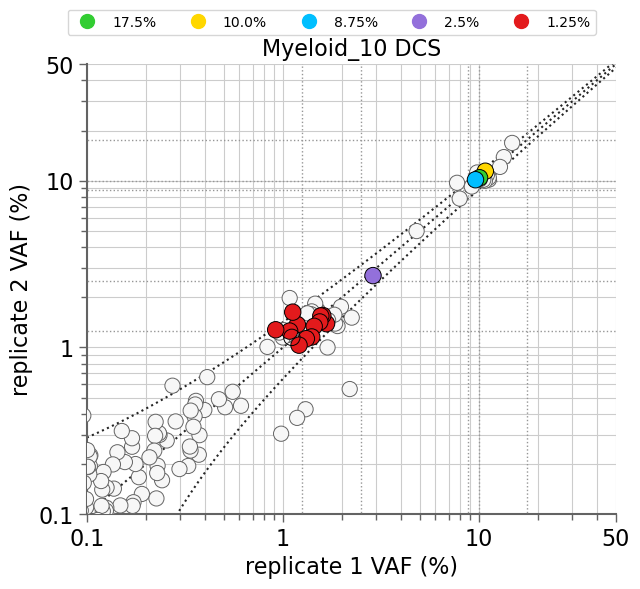

In [36]:
plot_validated_replicates_zoomed_in_10_dilution(Myeloid_10_reps_coord, Myeloid_10_base_changes_coord, Myeloid_10_mean_depth, 'Myeloid 10%', 'Myeloid_10', 'DCS', 4, [(0.0111, 0.0115, 0.005)])

ASXL1 p.W796C 0.05: [0, 0.00038284839203675346]
CBL p.S403F 0.05: not_detected
EZH2 p.R418Q 0.05: [0.0009115770282588879, 0]
FLT3 p.D835Y 0.05: not_detected
IDH1 p.R132C 0.05: [0, 0.0013395847287340924]
IDH2 p.R172K 0.05: [0.0005393743257820927, 0.0009823182711198428]
JAK2 p.V617F 0.05: not_detected
KRAS p.G13D 0.4: [0.0008771929824561404, 0.001260239445494644]
NRAS p.Q61L 0.1: [0.0008058017727639, 0]
RUNX1 p.M267I 0.35: [0.0016741071428571428, 0.002535496957403651]
SF3B1 p.G740E 0.05: [0, 0.0016891891891891893]
TET2 p.R1261H 0.05: [0.001292824822236587, 0]
TP53 p.S241F 0.05: [0.0006702412868632708, 0.002185792349726776]
BCOR p.Q1174fs*8 0.7: [0.0005589714924538849, 0.001756697408871322]
FLT3 ITD 0.05: not_detected
NPM1 p.W288fs*12 0.05: not_detected
JAK2 p.F537-K539>L 0.05: not_detected

total variants in replicate 1 =  0
total variants in replicate 1 <0.5% VAF =  0
total variants in replicate 2 =  0
total variants in replicate 2 <0.5% VAF =  0
total variants present in both replicate

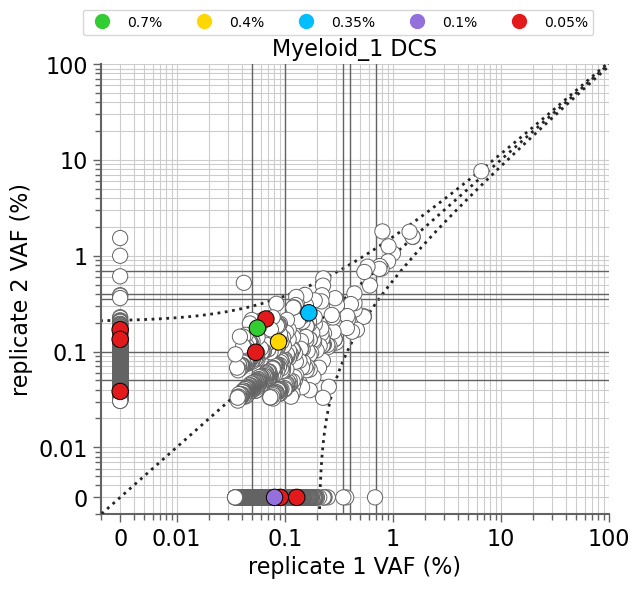

In [37]:
plot_validated_replicates(Myeloid_1_reps_coord, Myeloid_1_base_changes_coord, Myeloid_1_mean_depth, 'Myeloid 1%', 'Myeloid_1', 'DCS', 100, [(0, 0, 0.0005)])

ASXL1 p.W796C 0.05: [0.0004037141703673799, 0]
CBL p.S403F 0.05: not_detected
EZH2 p.R418Q 0.05: not_detected
FLT3 p.D835Y 0.05: not_detected
IDH1 p.R132C 0.05: [0.00199203187250996, 0.0005817335660267597]
IDH2 p.R172K 0.05: not_detected
JAK2 p.V617F 0.05: not_detected
KRAS p.G13D 0.4: [0.0006049606775559589, 0.0005561735261401557]
NRAS p.Q61L 0.1: not_detected
RUNX1 p.M267I 0.35: [0.0014829461196243204, 0.0009229349330872173]
SF3B1 p.G740E 0.05: not_detected
TET2 p.R1261H 0.05: not_detected
TP53 p.S241F 0.05: [0, 0.0004870920603994155]
BCOR p.Q1174fs*8 0.7: [0.00044822949350067237, 0]
FLT3 ITD 0.05: not_detected
NPM1 p.W288fs*12 0.05: not_detected
JAK2 p.F537-K539>L 0.05: not_detected

total variants in replicate 1 =  0
total variants in replicate 1 <0.5% VAF =  0
total variants in replicate 2 =  0
total variants in replicate 2 <0.5% VAF =  0
total variants present in both replicate 1 and 2 =  0
total variants present in both replicate 1 and 2 <0.5% VAF =  0
total variants present in 

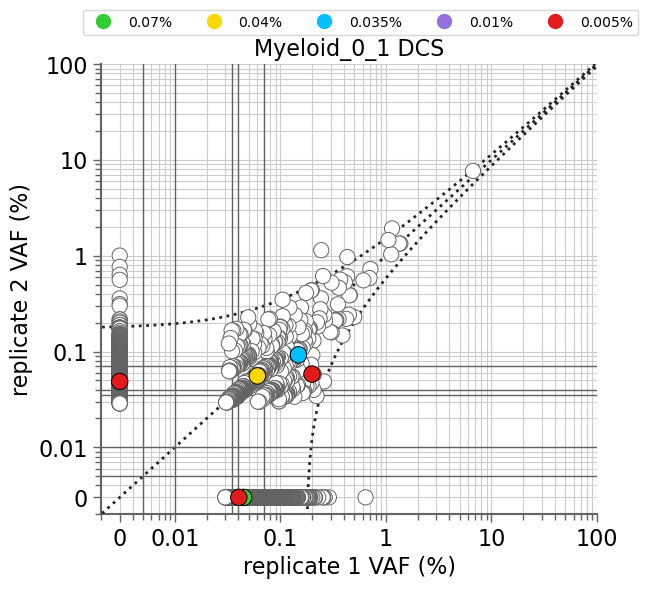

In [38]:
plot_validated_replicates(Myeloid_0_1_reps_coord, Myeloid_0_1_base_changes_coord, Myeloid_0_1_mean_depth, 'Myeloid 0.1%', 'Myeloid_0_1', 'DCS', 1000, [(0, 0, 0.0005)])

In [39]:
# create dataframe:
validated_results_dict = {}

for k, v in all_validated_variants.items():    
#     print(k, v)
    coordinate = k
    expected_100_vaf = v*100
    expected_10_vaf = v*100/10
    expected_1_vaf = v*100/100
    expected_0_1_vaf = v*100/1000
    annotation = validated_variant_annotation[coordinate][0]
    variant_type = validated_variant_annotation[coordinate][1]
    
    if coordinate in Myeloid_100_reps_coord.keys():
        M_100A_VAF = round(Myeloid_100_reps_coord[coordinate][0]*100, 3)
        M_100B_VAF = round(Myeloid_100_reps_coord[coordinate][1]*100, 3)
    else:
        M_100A_VAF = 0
        M_100B_VAF = 0
        
    if coordinate in Myeloid_10_reps_coord.keys():
        M_10A_VAF = round(Myeloid_10_reps_coord[coordinate][0]*100, 3)
        M_10B_VAF = round(Myeloid_10_reps_coord[coordinate][1]*100, 3)
    else:
        M_10A_VAF = 0
        M_10B_VAF = 0
        
    if coordinate in Myeloid_1_reps_coord.keys():
        M_1A_VAF = round(Myeloid_1_reps_coord[coordinate][0]*100, 3)
        M_1B_VAF = round(Myeloid_1_reps_coord[coordinate][1]*100, 3)
    else:
        M_1A_VAF = 0
        M_1B_VAF = 0
        
    if coordinate in Myeloid_0_1_reps_coord.keys():
        M_0_1A_VAF = round(Myeloid_0_1_reps_coord[coordinate][0]*100, 3)
        M_0_1B_VAF = round(Myeloid_0_1_reps_coord[coordinate][1]*100, 3)
    else:
        M_0_1A_VAF = 0
        M_0_1B_VAF = 0
        
    validated_results_dict[annotation] = {'Myeloid 100%':{'Expected VAF (%)': expected_100_vaf, 'Replicate 1 VAF (%)': M_100A_VAF, 'Replicate 2 VAF (%)': M_100B_VAF},
                         'Myeloid 10%':{'Expected VAF (%)': expected_10_vaf, 'Replicate 1 VAF (%)': M_10A_VAF, 'Replicate 2 VAF (%)': M_10B_VAF},
                         'Myeloid 1%':{'Expected VAF (%)': expected_1_vaf, 'Replicate 1 VAF (%)': M_1A_VAF, 'Replicate 2 VAF (%)': M_1B_VAF},
                         'Myeloid 0.1%':{'Expected VAF (%)': expected_0_1_vaf, 'Replicate 1 VAF (%)': M_0_1A_VAF, 'Replicate 2 VAF (%)': M_0_1B_VAF}}
        

In [ ]:
df = pd.DataFrame.from_dict(validated_results_dict, orient = 'index')
myeloid_100_df = df['Myeloid 100%'].apply(pd.Series)
myeloid_10_df = df['Myeloid 10%'].apply(pd.Series)
myeloid_1_df = df['Myeloid 1%'].apply(pd.Series)
myeloid_0_1_df = df['Myeloid 0.1%'].apply(pd.Series)
df_all = pd.concat([myeloid_100_df, myeloid_10_df, myeloid_1_df, myeloid_0_1_df], axis = 1)

## Look at dilutions

In [47]:
color10 = '#2c7fb8' #c1
color1 = '#7fcdbb' #c6
color01 = '#edf8b1' #c4

In [ ]:
def plot_100_against_dilution(Myeloid_100_reps, dilution_reps, Myeloid_100_mean_depth, SEM_reps, rep_mean_depth,  color, dilution_factor, label, ax):
            
    M100_VAFs = []
    dilution_VAFs = []
    
    mean_depth = np.mean([Myeloid_100_mean_depth, rep_mean_depth])
    
    both_variants_dilutions = []
    for dictionary in [Myeloid_100_reps, dilution_reps]:
        for k in dictionary.keys():
            if k not in both_variants_dilutions:
                if k not in SEM_reps:
                    both_variants_dilutions.append(k)
                    
    # print(len(both_variants_dilutions))

    for variant in both_variants_dilutions: #just look at 1 of the replicates (A replicate for both)
        if variant in Myeloid_100_reps.keys():
            M100_VAFs.append(Myeloid_100_reps[variant][0])
            M100_VAFs.append(Myeloid_100_reps[variant][1])
        else:
            M100_VAFs.append(1e-5)
            M100_VAFs.append(1e-5)
        if variant in dilution_reps.keys():
            dilution_VAFs.append(dilution_reps[variant][0])
            dilution_VAFs.append(dilution_reps[variant][1])
        else:
            dilution_VAFs.append(1e-5)
            dilution_VAFs.append(1e-5)

    ax.scatter(M100_VAFs, dilution_VAFs, color = color, zorder = 500, s = 75, lw = 0.7, edgecolor = 'k', alpha = 1.0, label = label)
    ax.plot([1e-5*dilution_factor, 1*dilution_factor],[1e-5, 1],color = color, lw = 2.5, linestyle = ':', zorder = 50)
    
    #Error lines
    D = mean_depth
    x1=np.logspace(-4, 0, 10000)
    y1=np.logspace(-4, 0, 10000)
    f_low=[f-1.96*((f/D)**0.5) for f in x1]
    f_low2=[]
    for f in f_low:
        if f<0:
            f_low2.append(1e-8)
        else:
            f_low2.append(f)

    print('number of variants in '+str(100/dilution_factor)+'% dilution = '+str(len(dilution_VAFs)))
    
    return ax

number of variants in 25.0% dilution = 20944
number of variants in 1.0% dilution = 16542
number of variants in 0.16666666666666666% dilution = 18288


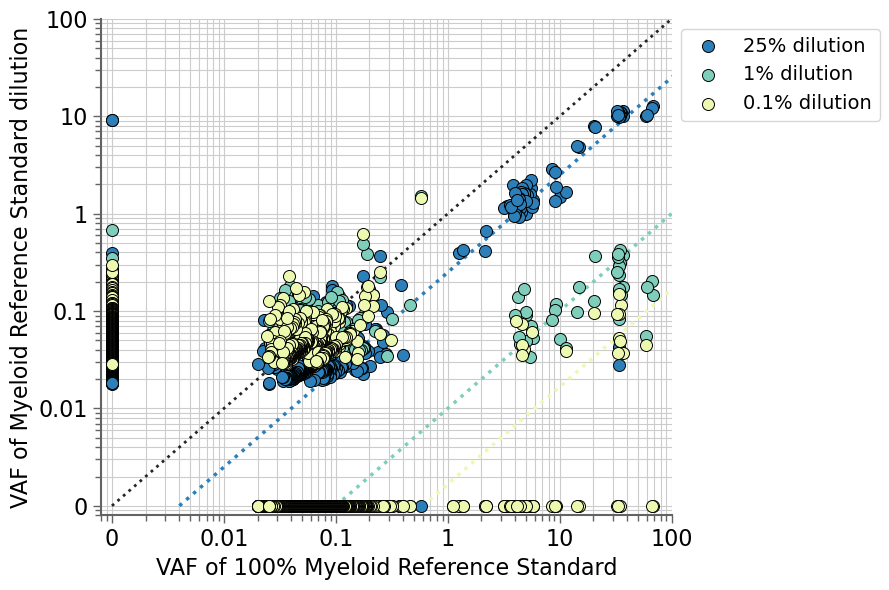

In [50]:
fig, ax1 = plt.subplots(1, 1, figsize = (9, 6))
axislabelfont = 16

plot_100_against_dilution(Myeloid_100_reps, Myeloid_10_reps, Myeloid_100_mean_depth, SEM_reps, Myeloid_10_mean_depth, color10, 4, '25% dilution', ax1)
plot_100_against_dilution(Myeloid_100_reps, Myeloid_1_reps, Myeloid_100_mean_depth, SEM_reps, Myeloid_1_mean_depth, color1, 100, '1% dilution', ax1)
plot_100_against_dilution(Myeloid_100_reps, Myeloid_0_1_reps, Myeloid_100_mean_depth, SEM_reps, Myeloid_0_1_mean_depth, color01, 600, '0.1% dilution', ax1)

ax1.plot([1e-5, 1], [1e-5, 1], color = grey5, lw = 2, linestyle = ':', zorder = 50)

ax1.legend(fontsize = 14, loc = 'upper left', bbox_to_anchor = (1.0, 1.0))


#Configure appearance of plot
for ax in [ax1]:
    ax.set_xlim(8e-6, 1)
    ax.set_ylim(8e-6, 1)

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_ylabel('VAF of Myeloid Reference Standard dilution', fontsize = 16)
    ax.set_xlabel('VAF of 100% Myeloid Reference Standard', fontsize = 16)
    ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 16)
    ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
    for axis in ['right', 'top']:
        ax.spines[axis].set_visible(False)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey4)

    x_major_ticks = [1e-5, 10**(-4), 10**(-3), 10**(-2), 10**(-1), 10**(0)]
    x_major_tick_labels = ["0", "0.01", "0.1", "1", "10", "100"]
    ax.set_xticks(x_major_ticks)
    ax.set_xticklabels(x_major_tick_labels, fontsize = axislabelfont)
    ax.set_yticks(x_major_ticks)
    ax.set_yticklabels(x_major_tick_labels, fontsize = axislabelfont)


    ax.grid(which = 'both', zorder = 0, color = grey2)

    plt.tight_layout()
    plt.show()